# 学習済みモデルの特徴空間・プロトタイプを可視化
BASELINE_DI.pyで生成した画像を対象に特徴量を可視化するためのノートブック

In [1]:
from pathlib import Path
import os, sys, json
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [2]:
# 例: 物理GPU1番だけを見せる
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"

In [ ]:
# === プロジェクトルートの指定 ===
# Notebook を CIDL-main の直下で開いているなら "." で OK
PROJECT_ROOT = Path("/home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL").resolve()
os.chdir(PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT))

from trainer import _set_device  # 既存のヘルパをそのまま使う
from utils.data_manager import DataManager
from utils import factory

# === 使いたい設定ファイルと、どの phase を可視化するか ===
CONFIG_PATH = "exps/BASELINE_DIMMD2/cifar.json"   # 適宜変更
PHASE_ID_REAL = 4                                 # ex) タスク3終了時のモデル → phase3.pkl
PHASE_ID_DI   = 5

# === json 読み込み → args にする ===
with open(CONFIG_PATH) as f:
    args = json.load(f)

# device を training と同じ形式 (list of torch.device) に変換
_set_device(args)

print("model_name:", args["model_name"])
print("dataset   :", args["dataset"])
print("device    :", args["device"])

model_name: baseline-dimmd2
dataset   : cifar100
device    : [device(type='cuda', index=0)]


## チェックポイントの設定

In [35]:
from glob import glob

def build_ckpt_dir(args, root=PROJECT_ROOT / "checkpoint"):
    """trainer / BaseLearner.save_checkpoint と同じ規則で checkpoint ディレクトリを作る"""
    folder = f"{args['lambda_fkd']}_{args['lambda_proto']}_" \
             f"{args['lambda_pes']}_{args['lambda_pgru']}_" \
             f"{args['lambda_unl']}"
    ckpt_dir = (
        root
        / args["model_name"]
        / args["log_name"]
        / args["dataset"]
        / str(args["init_cls"])
        / str(args["increment"])
        / folder
    )
    return ckpt_dir

ckpt_dir  = build_ckpt_dir(args)

#=== 実画像から特徴量を取り出すためのモデル読み込み ===#
ckpt_path_real = ckpt_dir / f"phase{PHASE_ID_REAL}.pkl"

print("ckpt_dir :", ckpt_dir)
print("ckpt_path:", ckpt_path_real, "(exists:", ckpt_path_real.exists(), ")")

# もし exists が False のときは、pattern で探す fallback も書いておくと楽
if not ckpt_path_real.exists():
    cand_real = glob(str(ckpt_dir / f"phase{PHASE_ID_REAL}*.pkl"))
    print("fallback candidates:", cand_real)

#=== DI画像から特徴量を取り出すためのモデル読み込み ===#
ckpt_path_di = ckpt_dir / f"phase{PHASE_ID_DI}.pkl"

print("ckpt_dir :", ckpt_dir)
print("ckpt_path:", ckpt_path_di, "(exists:", ckpt_path_di.exists(), ")")

# もし exists が False のときは、pattern で探す fallback も書いておくと楽
if not ckpt_path_di.exists():
    cand_di = glob(str(ckpt_dir / f"phase{PHASE_ID_DI}*.pkl"))
    print("fallback candidates:", cand_di)

ckpt_dir : /home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL/checkpoint/baseline-dimmd2/baseline/cifar100/50/5/10_10_0_0_20.0
ckpt_path: /home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL/checkpoint/baseline-dimmd2/baseline/cifar100/50/5/10_10_0_0_20.0/phase4.pkl (exists: True )
ckpt_dir : /home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL/checkpoint/baseline-dimmd2/baseline/cifar100/50/5/10_10_0_0_20.0
ckpt_path: /home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL/checkpoint/baseline-dimmd2/baseline/cifar100/50/5/10_10_0_0_20.0/phase5.pkl (exists: True )


## データマネージャーとモデルの作成

In [36]:
# === DataManager & model を構築 ===
data_manager = DataManager(
    dataset_name=args["dataset"],
    shuffle=args["shuffle"],
    seed=args["seed"][0],
    init_cls=args["init_cls"],
    increment=args["increment"],
)

#=== 実画像用のモデル作成 ===#
model_real = factory.get_model(args["model_name"], args)
model_real._network.to(args["device"][0])
model_real._device = args["device"][0]

# checkpoint ロード
ckpt = torch.load(ckpt_path_real, map_location=model_real._device)
state_dict = ckpt["model_state_dict"]

# 1) checkpoint から fc の出力次元を読む
if "fc.weight" in state_dict:
    out_dim = state_dict["fc.weight"].shape[0]  # logits の次元数
    # 2) その次元数に合わせて fc を作成
    model_real._network.update_fc(out_dim)

# 3) その上で state_dict をロード
model_real._network.load_state_dict(state_dict)

# protos, forget_classes も保存されていれば復元
if "protos" in ckpt:
    model_real._protos = ckpt["protos"]
if "forget_classes" in ckpt and hasattr(model_real, "forget_classes"):
    model_real.forget_classes = ckpt["forget_classes"]

model_real.data_manager = data_manager

print("loaded tasks =", ckpt.get("tasks", "N/A"))
print("forget_classes:", getattr(model_real, "forget_classes", None))


#=== DI画像用のモデル作成 ===#
model_di = factory.get_model(args["model_name"], args)
model_di._network.to(args["device"][0])
model_di._device = args["device"][0]

# checkpoint ロード
ckpt = torch.load(ckpt_path_di, map_location=model_real._device)
state_dict = ckpt["model_state_dict"]

# 1) checkpoint から fc の出力次元を読む
if "fc.weight" in state_dict:
    out_dim = state_dict["fc.weight"].shape[0]  # logits の次元数
    # 2) その次元数に合わせて fc を作成
    model_di._network.update_fc(out_dim)

# 3) その上で state_dict をロード
model_di._network.load_state_dict(state_dict)

# protos, forget_classes も保存されていれば復元
if "protos" in ckpt:
    model_di._protos = ckpt["protos"]
if "forget_classes" in ckpt and hasattr(model_real, "forget_classes"):
    model_di.forget_classes = ckpt["forget_classes"]

model_di.data_manager = data_manager

print("loaded tasks =", ckpt.get("tasks", "N/A"))
print("forget_classes:", getattr(model_di, "forget_classes", None))

Files already downloaded and verified
Files already downloaded and verified


<ipython-input-36-3d645d570a34>:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path_real, map_location=model_real._device)


loaded tasks = 4
forget_classes: [0, 1, 2, 3, 4, 5, 50, 6, 55, 7, 60]
loaded tasks = 5
forget_classes: [0, 1, 2, 3, 4, 5, 50, 6, 55, 7, 60, 8, 65]


<ipython-input-36-3d645d570a34>:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path_di, map_location=model_real._device)


## 学習済みクラスなどの設定・確認

In [37]:
# === この phase で「見えている」クラス数を計算 ===
num_classes = args["init_cls"] + PHASE_ID_REAL * args["increment"]
num_classes = min(num_classes, data_manager.get_total_classnum())

# その時点での全クラス（モデルのラベル空間）
all_seen = np.arange(num_classes)

# MU 系モデルの場合：忘却クラス集合（relabel 後の ID）
forget_set = set(getattr(model_real, "forget_classes", []))

# 現在 phase で実際に存在する忘却クラスだけに絞る
forget = np.array(
    sorted([c for c in forget_set if c < num_classes]),
    dtype=int
)

# retain クラス = all_seen - forget
retain = np.setdiff1d(all_seen, forget)

print("num_classes :", num_classes)
print("all_seen    :", all_seen[:10], "... (total", len(all_seen), ")")
print("forget      :", forget)
print("retain      :", retain[:10], "... (total", len(retain), ")")


num_classes : 70
all_seen    : [0 1 2 3 4 5 6 7 8 9] ... (total 70 )
forget      : [ 0  1  2  3  4  5  6  7 50 55 60]
retain      : [ 8  9 10 11 12 13 14 15 16 17] ... (total 59 )


## model inversionによって生成した画像の読み込み＆特徴量の取り出し

In [38]:
def extract_features_from_di_pth(model, di_pth, batch_size=64):
    """
    DeepInversion で保存した .pth から
      - images: (N, 3, H, W)  …… すでに net 入力空間（Normalize 済み）
      - targets: (N,)         …… PRL のクラス index
    を読み、model._network.extract_vector で特徴を返す。
    """
    di_pth = Path(di_pth)
    assert di_pth.exists(), f"DeepInversion file not found: {di_pth}"

    # ---------- .pth をロード ----------
    di_ckpt = torch.load(di_pth, map_location="cpu")
    imgs_chw = di_ckpt["images"]          # (N, 3, H, W), たぶん uint8
    labels_t = di_ckpt["labels"].long()   # (N,)

    # torch.Tensor → numpy, CHW → HWC にして
    # DataManager.appendent 互換の形にする
    if isinstance(imgs_chw, torch.Tensor):
        imgs_chw = imgs_chw.cpu()
    if isinstance(labels_t, torch.Tensor):
        labels_t = labels_t.cpu()

    # (N,3,H,W) → (N,H,W,3)
    imgs_hwc = imgs_chw.permute(0, 2, 3, 1).numpy()
    labels_np = labels_t.numpy()

    # もし 0〜1 float で保存していたら 0〜255 に戻しておく（CIFAR/Tiny の train_data と揃える）
    if imgs_hwc.dtype in (np.float32, np.float64):
        imgs_hwc = np.clip(imgs_hwc * 255.0, 0, 255).astype(np.uint8)
    elif imgs_hwc.dtype != np.uint8:
        imgs_hwc = imgs_hwc.astype(np.uint8)

    data_manager = model.data_manager  # incremental_train でセットされているはず

    # ---------- 学習時と同じ DummyDataset / transform を作る ----------
    # indices=[] なので、appendent の DI 画像だけが Dataset に入る
    di_dataset = data_manager.get_dataset(
        indices=[],
        source="train",
        mode="test",                   # _sample_forget_memory_batch と同じ
        appendent=(imgs_hwc, labels_np),
        setup_replay=False,
    )

    di_loader = DataLoader(
        di_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=model.args.get("num_workers", 4),
        pin_memory=True,
    )

    # ---------- 特徴抽出 ----------
    device = model._device
    model._network.eval()

    feats = []
    all_labels = []

    with torch.no_grad():
        for _, inputs, targets in di_loader:   # DummyDataset と同じ (idx, image, label)
            inputs = inputs.to(device)
            targets = targets.to(device)

            vec = model._network.extract_vector(inputs)  # (B, feat_dim)
            feats.append(vec.cpu())
            all_labels.append(targets.cpu())

    feats = torch.cat(feats, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    return feats, all_labels



# 生成画像の保存場所：
base_path = "/home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL"
extra_path = "checkpoint/baseline-dimmd2/baseline/cifar100/50/5/10_10_0_0_20.0/di_task5/di_task5.pth"
DI_path = os.path.join(base_path, extra_path)

# 特徴量の取り出し
feat_di, labels_di = extract_features_from_di_pth(model_di, DI_path, batch_size=64)
print("feat_di.shape: ", feat_di.shape)


# ====== ここからクラスフィルタリング ======
di_target_classes = [10,12,14,16,18]

# labels_di ∈ di_target_classes のものだけ True になるマスク
mask = np.isin(labels_di, di_target_classes)

# 特徴とラベルをマスクで絞る
feat_di   = feat_di[mask]      # (N_filtered, D)
labels_di = labels_di[mask]    # (N_filtered,)

print("filtered feat_di.shape:   ", feat_di.shape)
print("filtered labels_di.shape: ", labels_di.shape)


<ipython-input-38-7c88fda95af3>:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  di_ckpt = torch.load(di_pth, map_location="cpu")


feat_di.shape:  (2480, 512)
filtered feat_di.shape:    (200, 512)
filtered labels_di.shape:  (200,)


## 実画像の特徴量の取り出し

In [39]:
# "all" / "forget" / "retain" / "manual" から選ぶ
TARGET_MODE = "manual"   # ← ここを変える

# manual のときに使うクラスID（モデル側のラベル空間）
MANUAL_CLASSES = [10,12,14,16,18]   # 例: 最初の数クラスだけ

if TARGET_MODE == "all":
    target_classes = all_seen
elif TARGET_MODE == "forget":
    target_classes = forget
elif TARGET_MODE == "retain":
    target_classes = retain
elif TARGET_MODE == "manual":
    target_classes = np.array(MANUAL_CLASSES, dtype=int)
else:
    raise ValueError("Unknown TARGET_MODE:", TARGET_MODE)

print("target_classes:", target_classes)

from torch.utils.data import DataLoader

# === 指定したクラスだけの test データセット ===
test_dataset = data_manager.get_dataset(
    indices=target_classes,
    source="train",
    mode="plot",
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=args["num_workers"],
    pin_memory=True,
)

# === 特徴抽出 ===
features, labels = model_real._extract_vectors(test_loader)  # features: (N, D), labels: (N,)
print("features:", features.shape, "labels:", labels.shape)

# 念のため：本当に target_classes だけか確認
print("unique labels in batch:", np.unique(labels))


# === プロトタイプを取り出す（target_classes に対応するものだけ） ===
proto_vecs = []
proto_labels = []

if hasattr(model_real, "_protos") and len(model_real._protos) > 0:
    for cls in target_classes:
        # checkpoint で保存済み & このタスクまでに構築済みのクラスだけ
        if cls in model_real._protos:
            proto_vecs.append(model_real._protos[cls])
            proto_labels.append(cls)

if len(proto_vecs) > 0:
    proto_vecs = np.stack(proto_vecs, axis=0)          # shape: (P, D)
    proto_labels = np.array(proto_labels, dtype=int)   # shape: (P,)
    print("num prototypes:", proto_vecs.shape[0])
else:
    proto_vecs = None
    proto_labels = None
    print("no prototypes found for target_classes.")



target_classes: [10 12 14 16 18]
features: (2500, 512) labels: (2500,)
unique labels in batch: [10 12 14 16 18]
num prototypes: 5


## t-sneによる次元削減

In [40]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# === subsample (特徴側だけ、必要なら) ===
max_points = 50000
if features.shape[0] > max_points:
    idx = np.random.choice(features.shape[0], max_points, replace=False)
    feat_vis = features[idx]
    labels_vis = labels[idx]
else:
    feat_vis = features
    labels_vis = labels

print("visualizing features:", feat_vis.shape[0])


# === t-SNE に入れるデータを結合（real → DeepInv → prototypes の順） ===

# まず実画像だけ
X_tsne = feat_vis
di_offset = None
proto_offset = None

# DeepInversion の特徴を後ろに足す
if 'feat_di' in globals():
    di_offset = X_tsne.shape[0]
    X_tsne = np.concatenate([X_tsne, feat_di], axis=0)
    print("after DI: ", X_tsne.shape)

# プロトタイプをさらに後ろに足す
if proto_vecs is not None and proto_vecs.shape[1] == feat_vis.shape[1]:
    proto_offset = X_tsne.shape[0]
    X_tsne = np.concatenate([X_tsne, proto_vecs], axis=0)
    print("after PR: ", X_tsne.shape)

print("X_tsne shape:", X_tsne.shape)
print("di_offset:", di_offset, "proto_offset:", proto_offset)


# === t-SNE ===
tsne = TSNE(
    n_components=2,
    init="pca",
    random_state=0,
    perplexity=30,
    learning_rate=200,
)
X_2d = tsne.fit_transform(X_tsne)



# 実画像
feat_2d = X_2d[:feat_vis.shape[0]]

# DeepInversion
if di_offset is not None:
    # DeepInv の終端は「proto があれば proto_offset、なければ 全体の終端」
    di_end = proto_offset if proto_offset is not None else X_2d.shape[0]
    di_2d = X_2d[di_offset:di_end]
else:
    di_2d = None

# プロトタイプ
if proto_offset is not None:
    proto_2d = X_2d[proto_offset:]
else:
    proto_2d = None



visualizing features: 2500
after DI:  (2700, 512)
after PR:  (2705, 512)
X_tsne shape: (2705, 512)
di_offset: 2500 proto_offset: 2700


## 保存先のディレクトリを設定

In [41]:
from glob import glob

def build_plot_dir(args, root=PROJECT_ROOT / "logs"):
    """trainer / BaseLearner.save_checkpoint と同じ規則で checkpoint ディレクトリを作る"""
    folder = f"{args['lambda_fkd']}_{args['lambda_proto']}_" \
             f"{args['lambda_pes']}_{args['lambda_pgru']}_" \
             f"{args['lambda_unl']}"
    plot_dir = (
        root
        / args["model_name"]
        / args["log_name"]
        / args["dataset"]
        / str(args["init_cls"])
        / str(args["increment"])
        / folder
        / "plot"
    )
    return plot_dir

plot_dir  = build_plot_dir(args)

print("plot_dir :", plot_dir)



plot_dir : /home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL/logs/baseline-dimmd2/baseline/cifar100/50/5/10_10_0_0_20.0/plot


## 可視化と保存

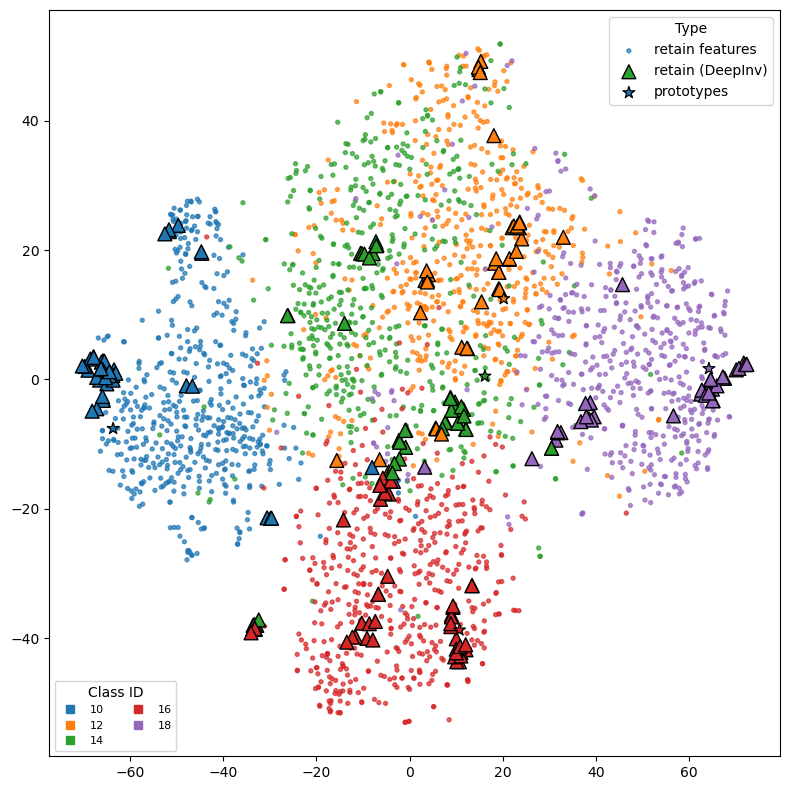

/home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL/logs/baseline-dimmd2/baseline/cifar100/50/5/10_10_0_0_20.0/plot/4_[10 12 14 16 18].pdf


In [42]:
from matplotlib.lines import Line2D  # まだインポートしてなければ追加

plt.figure(figsize=(8, 8))

# === 忘却クラス集合 ===
forget_set = set(getattr(model_real, "forget_classes", []))

# === 実画像 feature のうち忘却 / 維持に分割 ===
is_forget_feat = np.isin(labels_vis, list(forget_set))
idx_feat_forget = np.where(is_forget_feat)[0]
idx_feat_retain = np.where(~is_forget_feat)[0]

# === DeepInversion 特徴の忘却 / 維持に分割（di_2d が存在するときだけ） ===
if 'di_2d' in globals() and di_2d is not None:
    is_forget_di = np.isin(labels_di, list(forget_set))
    idx_di_forget = np.where(is_forget_di)[0]
    idx_di_retain = np.where(~is_forget_di)[0]
else:
    di_2d = None
    idx_di_forget = np.array([], dtype=int)
    idx_di_retain = np.array([], dtype=int)

# === 色を割り当てる対象となる全クラスID ===
all_label_values = [labels_vis]
# DeepInversion のクラスIDも色に反映
if di_2d is not None:
    all_label_values.append(labels_di)
if proto_labels is not None:
    all_label_values.append(proto_labels)

all_label_values = np.concatenate(all_label_values)
unique_labels = np.unique(all_label_values)

# === クラスごとの色をはっきり決める ===
# クラス数に応じて tab10 / tab20 を使い分け
if len(unique_labels) <= 10:
    cmap = plt.get_cmap("tab10")
else:
    cmap = plt.get_cmap("tab20")

# cls -> color の辞書
cls_color = {cls: cmap(i % cmap.N) for i, cls in enumerate(unique_labels)}

# === 維持クラスの実画像特徴（小さい丸） ===
if len(idx_feat_retain) > 0:
    colors_retain = [cls_color[int(lbl)] for lbl in labels_vis[idx_feat_retain]]
    plt.scatter(
        feat_2d[idx_feat_retain, 0],
        feat_2d[idx_feat_retain, 1],
        c=colors_retain,
        s=8,
        alpha=0.7,
        marker="o",
        label="retain features",
    )

# === 忘却クラスの実画像特徴（小さい ×） ===
if len(idx_feat_forget) > 0:
    colors_forget = [cls_color[int(lbl)] for lbl in labels_vis[idx_feat_forget]]
    plt.scatter(
        feat_2d[idx_feat_forget, 0],
        feat_2d[idx_feat_forget, 1],
        c=colors_forget,
        s=16,
        alpha=0.8,
        marker="x",
        linewidths=0.8,
        label="forget features",
    )

# === 維持クラスの DeepInversion 特徴（小さい三角） ===
if di_2d is not None and len(idx_di_retain) > 0:
    colors_di_retain = [cls_color[int(lbl)] for lbl in labels_di[idx_di_retain]]
    plt.scatter(
        di_2d[idx_di_retain, 0],
        di_2d[idx_di_retain, 1],
        c=colors_di_retain,
        s=100,
        alpha=1.0,
        marker="^",
        edgecolors="black",
        label="retain (DeepInv)",
    )

# === 忘却クラスの DeepInversion 特徴（少し大きい三角） ===
if di_2d is not None and len(idx_di_forget) > 0:
    colors_di_forget = [cls_color[int(lbl)] for lbl in labels_di[idx_di_forget]]
    plt.scatter(
        di_2d[idx_di_forget, 0],
        di_2d[idx_di_forget, 1],
        c=colors_di_forget,
        # s=60,
        # alpha=0.9,
        s=100,
        alpha=1.0,
        marker="^",
        edgecolors="black",
        linewidths=0.6,
        label="forget (DeepInv)",
    )

# === プロトタイプ（大きい★） ===
if proto_2d is not None:
    colors_proto = [cls_color[int(lbl)] for lbl in proto_labels]
    plt.scatter(
        proto_2d[:, 0],
        proto_2d[:, 1],
        c=colors_proto,
        s=80,
        marker="*",
        edgecolors="black",
        linewidths=0.9,
        label="prototypes",
    )

# === legend を2段構成にする ===
# 1) 形状ごとの legend（retain / forget / DeepInv / prototypes）
handles_type, labels_type = plt.gca().get_legend_handles_labels()
type_legend = plt.legend(
    handles_type,
    labels_type,
    loc="upper right",
    title="Type",
)
plt.gca().add_artist(type_legend)  # この legend を固定

# 2) クラスIDごとの色 legend
class_handles = []
for cls in unique_labels:
    h = Line2D(
        [], [],
        marker="s", linestyle="",
        color=cls_color[cls],
        label=str(cls),
    )
    class_handles.append(h)

plt.legend(
    handles=class_handles,
    loc="lower left",
    title="Class ID",
    ncol=2,          # クラス数に応じて調整
    fontsize=8,
)

# plt.title(f"Feature space with prototypes & DeepInv (phase {PHASE_ID}, mode={TARGET_MODE})")
plt.tight_layout()

# pdf として保存
save_name = f"{PHASE_ID_REAL}_{target_classes}.pdf"
if not os.path.exists(plot_dir):
    os.mkdir(plot_dir)
save_path = os.path.join(plot_dir, save_name)
plt.savefig(save_path)
plt.show()

print(save_path)